# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Import library utama untuk analisis dan preprocessing
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Definisi path agar notebook reproducible dijalankan dari folder mana pun
BASE_DIR = Path.cwd().resolve()
PROJECT_DIR = BASE_DIR.parent if BASE_DIR.name == 'preprocessing' else BASE_DIR
RAW_PATH = PROJECT_DIR / '.workflow' / 'namadataset_raw' / 'phishing_email_detection_2026_dataset.csv'
OUTPUT_PATH = PROJECT_DIR / 'preprocessing' / 'phishing_email_detection_2026_dataset_preprocessing.csv'
print(f'Raw path: {RAW_PATH}')
print(f'Output path: {OUTPUT_PATH}')

Raw path: C:\Users\Lenovo\OneDrive\Documents\Praktikum dan Dokumen\python Project\dicoding\Membangun Sistem ML\SMSML\.workflow\namadataset_raw\phishing_email_detection_2026_dataset.csv
Output path: C:\Users\Lenovo\OneDrive\Documents\Praktikum dan Dokumen\python Project\dicoding\Membangun Sistem ML\SMSML\preprocessing\phishing_email_detection_2026_dataset_preprocessing.csv


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Data loading
df = pd.read_csv(RAW_PATH)

print('Shape dataset:', df.shape)
display(df.head())

print('\nInfo dataset:')
display(df.info())

print('\nJumlah nilai unik per kolom:')
display(df.nunique())

Shape dataset: (1500, 9)


,email_id,sender_email,subject,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing
0,1,harrisonsandra@paypal-alert.com,Meeting Reminder,0,1,2,0,227,0
1,2,randyharris@bankverify.net,Urgent Account Verification,1,1,9,7,59,1
2,3,adam13@outlook.com,Suspicious Login Attempt,1,1,8,10,67,1
3,4,kennethfisher@company-secure.com,Suspicious Login Attempt,0,1,9,8,102,1
4,5,wsandoval@paypal-alert.com,Your Password Will Expire,1,0,7,4,96,1



Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   email_id            1500 non-null   int64 
 1   sender_email        1500 non-null   object
 2   subject             1500 non-null   object
 3   has_link            1500 non-null   int64 
 4   has_attachment      1500 non-null   int64 
 5   urgency_score       1500 non-null   int64 
 6   spelling_errors     1500 non-null   int64 
 7   email_length_words  1500 non-null   int64 
 8   is_phishing         1500 non-null   int64 
dtypes: int64(7), object(2)
memory usage: 105.6+ KB


None


Jumlah nilai unik per kolom:


email_id              1500
sender_email          1499
subject                 10
has_link                 2
has_attachment           2
urgency_score            9
spelling_errors         11
email_length_words     276
is_phishing              2
dtype: int64

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Descriptive statistics untuk kolom numerik:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
email_id,1500.0,NaN,NaN,NaN,750.5,433.157015,1.0,375.75,750.5,1125.25,1500.0
sender_email,1500,1499,kbrown@bankverify.net,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subject,1500,10,Claim Your Reward Now,167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_link,1500.0,NaN,NaN,NaN,0.629333,0.483144,0.0,0.0,1.0,1.0,1.0
has_attachment,1500.0,NaN,NaN,NaN,0.512667,0.500006,0.0,0.0,1.0,1.0,1.0
urgency_score,1500.0,NaN,NaN,NaN,5.722667,3.002182,1.0,3.0,5.0,8.0,10.0
spelling_errors,1500.0,NaN,NaN,NaN,3.708,3.209819,0.0,1.0,2.0,6.0,10.0
email_length_words,1500.0,NaN,NaN,NaN,132.559333,79.31597,20.0,72.0,108.0,193.0,300.0
is_phishing,1500.0,NaN,NaN,NaN,0.493333,0.500122,0.0,0.0,0.0,1.0,1.0



Missing values per kolom:


,missing_count
email_id,0
sender_email,0
subject,0
has_link,0
has_attachment,0
urgency_score,0
spelling_errors,0
email_length_words,0
is_phishing,0


Jumlah baris duplikat: 0


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11708\2512611551.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='is_phishing', palette='Set2')


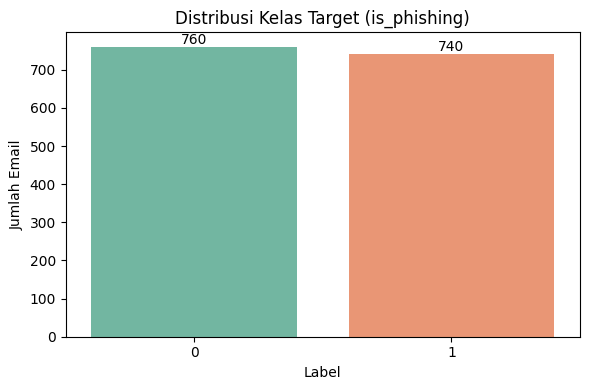

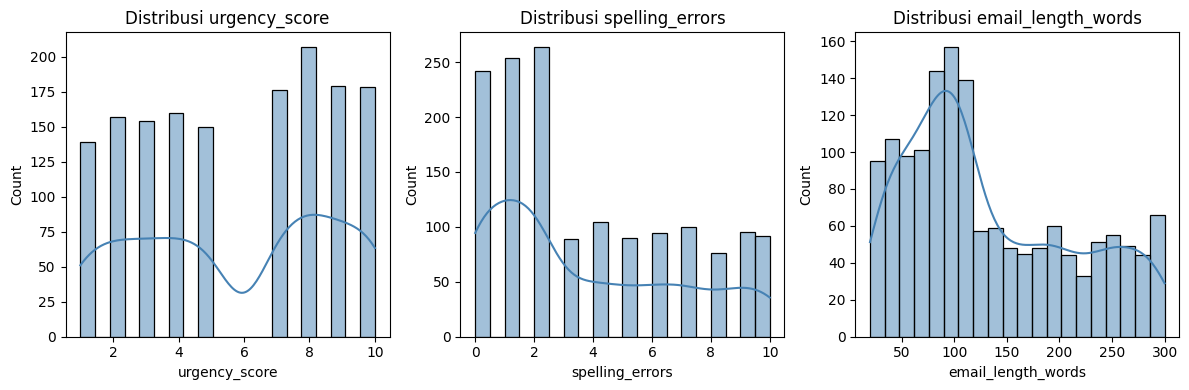

In [3]:
# EDA: statistik dasar, kualitas data, dan distribusi target
print('Descriptive statistics untuk kolom numerik:')
display(df.describe(include='all').transpose())

print('\nMissing values per kolom:')
display(df.isna().sum().to_frame('missing_count'))

duplicate_count = df.duplicated().sum()
print(f'Jumlah baris duplikat: {duplicate_count}')

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='is_phishing', palette='Set2')
ax.set_title('Distribusi Kelas Target (is_phishing)')
ax.set_xlabel('Label')
ax.set_ylabel('Jumlah Email')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

numeric_cols = ['urgency_score', 'spelling_errors', 'email_length_words']
plt.figure(figsize=(12, 4))
for i, col in enumerate(numeric_cols, start=1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True, bins=20, color='steelblue')
    plt.title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# Preprocessing: pembersihan, transformasi teks, dan penyimpanan dataset siap latih
def clean_text(value: str) -> str:
    value = str(value).lower().strip()
    value = re.sub(r'[^a-z0-9\s]', ' ', value)
    value = re.sub(r'\s+', ' ', value)
    return value

df_prep = df.copy()

# 1) Hapus missing values
df_prep = df_prep.dropna()

# 2) Hapus duplikat
df_prep = df_prep.drop_duplicates()

# 3) Normalisasi teks
df_prep['sender_email_clean'] = df_prep['sender_email'].apply(clean_text)
df_prep['subject_clean'] = df_prep['subject'].apply(clean_text)

# 4) Feature engineering ringan berbasis teks
df_prep['sender_domain'] = df_prep['sender_email'].str.split('@').str[-1].str.lower().str.strip()
df_prep['subject_word_count'] = df_prep['subject_clean'].str.split().str.len()

# 5) Pastikan tipe data konsisten untuk fitur numerik dan target
numeric_cols = ['has_link', 'has_attachment', 'urgency_score', 'spelling_errors', 'email_length_words', 'subject_word_count', 'is_phishing']
for col in numeric_cols:
    df_prep[col] = pd.to_numeric(df_prep[col], errors='coerce')

df_prep = df_prep.dropna(subset=numeric_cols)
df_prep[numeric_cols] = df_prep[numeric_cols].astype(int)

# Simpan output preprocessing
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df_prep.to_csv(OUTPUT_PATH, index=False)

print('Shape sebelum preprocessing:', df.shape)
print('Shape sesudah preprocessing:', df_prep.shape)
print(f'Hasil preprocessing disimpan ke: {OUTPUT_PATH}')
display(df_prep.head())

Shape sebelum preprocessing: (1500, 9)
Shape sesudah preprocessing: (1500, 13)
Hasil preprocessing disimpan ke: C:\Users\Lenovo\OneDrive\Documents\Praktikum dan Dokumen\python Project\dicoding\Membangun Sistem ML\SMSML\preprocessing\phishing_email_detection_2026_dataset_preprocessing.csv


,email_id,sender_email,subject,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing,sender_email_clean,subject_clean,sender_domain,subject_word_count
0,1,harrisonsandra@paypal-alert.com,Meeting Reminder,0,1,2,0,227,0,harrisonsandra paypal alert com,meeting reminder,paypal-alert.com,2
1,2,randyharris@bankverify.net,Urgent Account Verification,1,1,9,7,59,1,randyharris bankverify net,urgent account verification,bankverify.net,3
2,3,adam13@outlook.com,Suspicious Login Attempt,1,1,8,10,67,1,adam13 outlook com,suspicious login attempt,outlook.com,3
3,4,kennethfisher@company-secure.com,Suspicious Login Attempt,0,1,9,8,102,1,kennethfisher company secure com,suspicious login attempt,company-secure.com,3
4,5,wsandoval@paypal-alert.com,Your Password Will Expire,1,0,7,4,96,1,wsandoval paypal alert com,your password will expire,paypal-alert.com,4
